In [275]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Load dữ liệu

In [276]:
df = pd.read_csv('../../../DATA/CRAWL/kc_house_data_NaN.csv')

In [277]:
df.head()

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [278]:
df.shape

(21613, 22)

In [279]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     21613 non-null  int64  
 1   id             21613 non-null  int64  
 2   date           21613 non-null  object 
 3   price          21613 non-null  float64
 4   bedrooms       21600 non-null  float64
 5   bathrooms      21603 non-null  float64
 6   sqft_living    21613 non-null  int64  
 7   sqft_lot       21613 non-null  int64  
 8   floors         21613 non-null  float64
 9   waterfront     21613 non-null  int64  
 10  view           21613 non-null  int64  
 11  condition      21613 non-null  int64  
 12  grade          21613 non-null  int64  
 13  sqft_above     21613 non-null  int64  
 14  sqft_basement  21613 non-null  int64  
 15  yr_built       21613 non-null  int64  
 16  yr_renovated   21613 non-null  int64  
 17  zipcode        21613 non-null  int64  
 18  lat   

In [280]:
df.describe()

,Unnamed: 0,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21613.00000,2.161300e+04,2.161300e+04,21600.000000,21603.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,10806.00000,4.580302e+09,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,...,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,6239.28002,2.876566e+09,3.671272e+05,0.926657,0.768996,918.440897,4.142051e+04,0.539989,0.086517,0.766318,...,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,0.00000,1.000102e+06,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,5403.00000,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,10806.00000,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,16209.00000,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,21612.00000,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,...,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


# Xử lý dữ liệu trùng lặp

In [281]:
df.duplicated().sum()

np.int64(0)

# EDA

In [282]:
df.isnull().sum()

Unnamed: 0        0
id                0
date              0
price             0
bedrooms         13
bathrooms        10
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
grade             0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
zipcode           0
lat               0
long              0
sqft_living15     0
sqft_lot15        0
dtype: int64

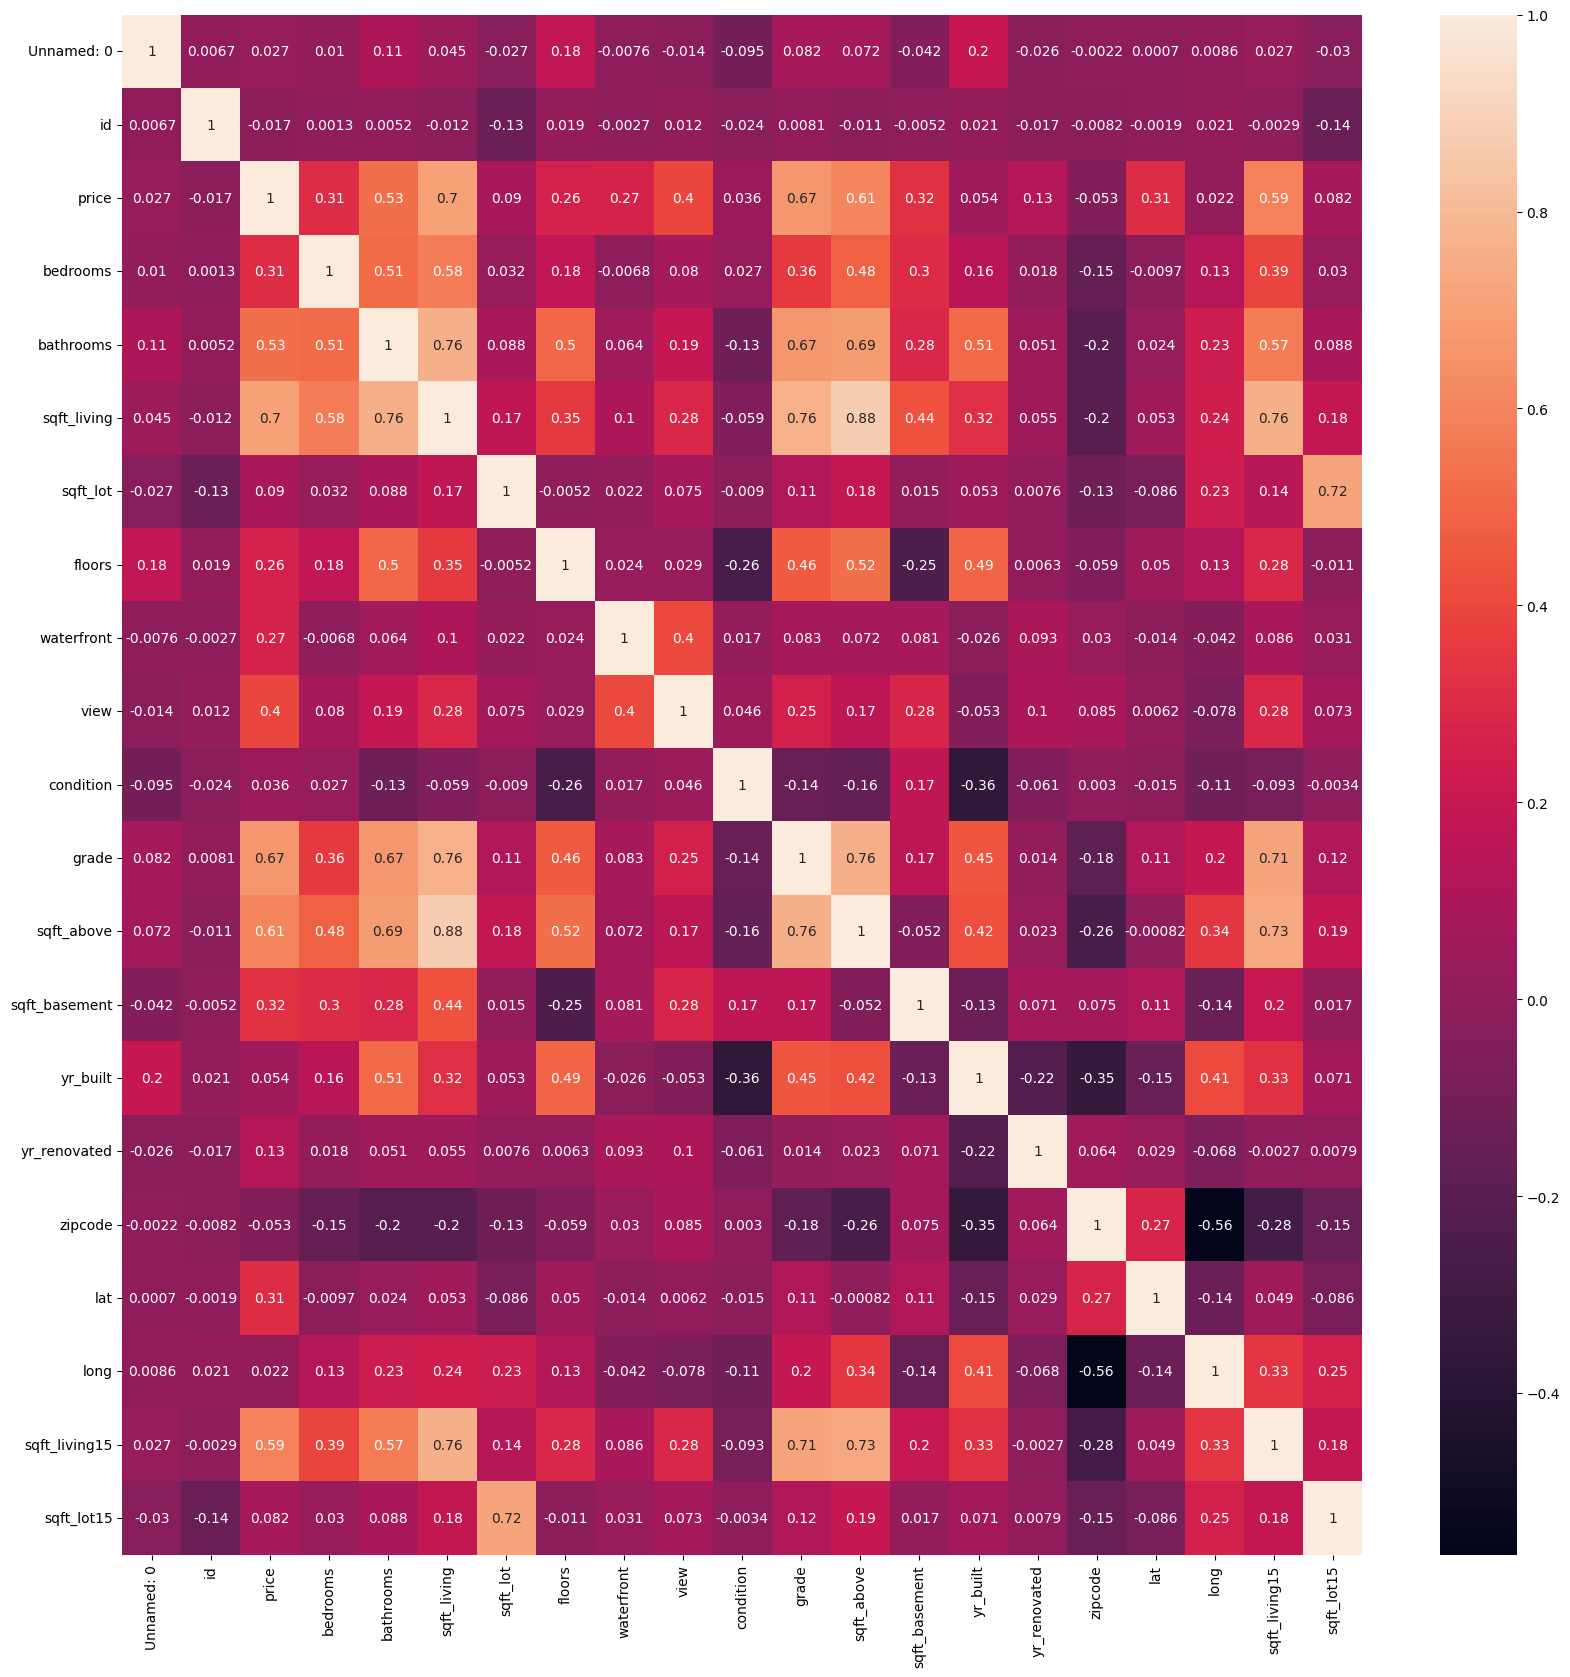

In [283]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(numeric_only=True), annot=True);

In [284]:
df.corr(numeric_only=True)['price'].abs().sort_values(ascending=False)

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525885
view             0.397293
sqft_basement    0.323816
bedrooms         0.308890
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
zipcode          0.053203
condition        0.036362
Unnamed: 0       0.027372
long             0.021626
id               0.016762
Name: price, dtype: float64

# Xử lý missing value

In [285]:
df1 = df.copy()

In [328]:
df1['bedrooms'].fillna(df1['bedrooms'].median())
df1['bathrooms'].fillna(df1['bathrooms'].median())

0        1.00
1        2.25
2        1.00
3        3.00
4        2.00
         ... 
21608    2.50
21609    2.50
21610    0.75
21611    2.50
21612    0.75
Name: bathrooms, Length: 21613, dtype: float64

In [287]:
df1.isnull().sum()

Unnamed: 0       0
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

# Xử lý outlier

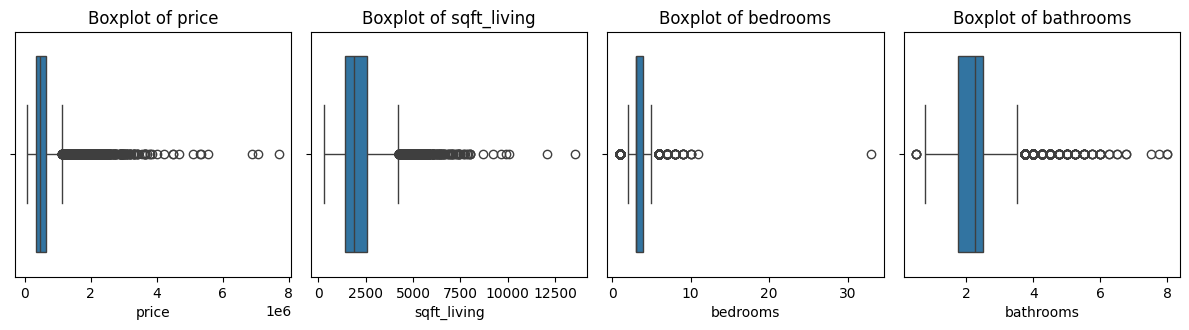

In [288]:
#Kiểm tra ngoại lại bằng boxplot
cols_to_check = ['price', 'sqft_living', 'bedrooms', 'bathrooms']

plt.figure(figsize=(12, 6))
for i, col in enumerate(cols_to_check, 1):
     plt.subplot(2, 4, i)
     sns.boxplot(x=df1[col])
     plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [289]:
df2_ = df1.copy()

In [290]:
# Dùng phướng pháp Log transformation cho price và sqft_living
df2_['price_log'] = np.log1p(df2_['price'])
df2_['sqft_living_log'] = np.log1p(df2_['sqft_living'])

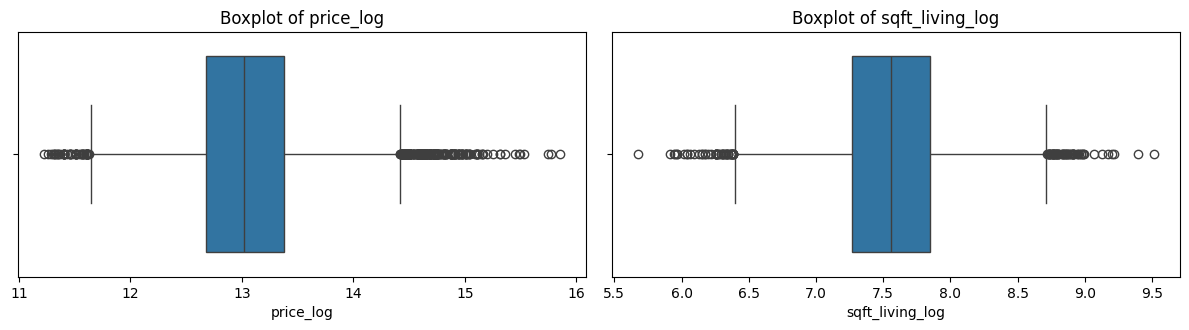

In [291]:
cols_to_check = ['price_log', 'sqft_living_log']

plt.figure(figsize=(12, 6))
for i, col in enumerate(cols_to_check, 1):
     plt.subplot(2, 2, i)
     sns.boxplot(x=df2_[col])
     plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [292]:
# Dùng phương pháp IQR để xác định ngưỡng cho outliers với cột bedrooms
Q1 = df2_['bedrooms'].quantile(0.25)
Q3 = df2_['bedrooms'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
df2_[(df2_.bedrooms < lower_limit) | (df2_.bedrooms > upper_limit)]

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price_log,sqft_living_log
154,154,7920100045,20140516T000000,350000.0,1.0,1.00,700,5100,1.0,0,...,0,1942,0,98115,47.6790,-122.300,1010,5100,12.765691,6.552508
209,209,6300000550,20140717T000000,464000.0,6.0,3.00,2300,3404,2.0,0,...,700,1920,1994,98133,47.7067,-122.343,1560,1312,13.047642,7.741099
232,232,9264902050,20141121T000000,315000.0,6.0,2.75,2940,7350,1.0,0,...,1160,1978,0,98023,47.3103,-122.339,2120,8236,12.660331,7.986505
239,239,5152100060,20140529T000000,472000.0,6.0,2.50,4410,14034,1.0,0,...,2060,1965,0,98003,47.3376,-122.324,2600,13988,13.064736,8.391857
264,264,2123039032,20141027T000000,369900.0,1.0,0.75,760,10079,1.0,1,...,0,1936,0,98070,47.4683,-122.438,1230,14267,12.820991,6.634633
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21375,21375,6061500100,20140717T000000,1174660.0,6.0,3.50,4310,7760,2.0,0,...,1050,2013,0,98059,47.5297,-122.155,4620,10217,13.976490,8.368925
21443,21443,3278600750,20150407T000000,250000.0,1.0,1.50,1180,1688,2.0,0,...,110,2007,0,98126,47.5490,-122.372,1380,2059,12.429220,7.074117
21519,21519,1702901618,20150407T000000,420000.0,1.0,2.00,1070,675,2.0,0,...,190,2007,0,98118,47.5574,-122.284,1220,788,12.948012,6.976348
21522,21522,603000555,20150302T000000,462500.0,6.0,3.00,2390,4000,2.0,0,...,0,2014,0,98118,47.5173,-122.286,1680,5000,13.044404,7.779467


In [293]:
outliers = df2_[(df2_.bedrooms < lower_limit) | (df2_.bedrooms > upper_limit)]
bang_tong_hop = outliers['bedrooms'].value_counts().sort_index().reset_index()
bang_tong_hop.columns = ['Số phòng ngủ (Outlier)', 'Số lượng căn nhà']
print("BẢNG TỔNG HỢP CÁC CĂN NHÀ NGOẠI LAI (OUTLIERS):")
print(bang_tong_hop)

BẢNG TỔNG HỢP CÁC CĂN NHÀ NGOẠI LAI (OUTLIERS):
   Số phòng ngủ (Outlier)  Số lượng căn nhà
0                     1.0               199
1                     6.0               272
2                     7.0                38
3                     8.0                13
4                     9.0                 6
5                    10.0                 3
6                    11.0                 1
7                    33.0                 1


In [294]:
# Giới hạn số phòng ngủ trong khoảng từ 1 đến 6
# Căn nào 0 phòng ngủ sẽ được nâng lên 1, căn nào > 6 (như 11, 33) sẽ bị hạ xuống 6
df2_['bedrooms'] = np.clip(df2_['bedrooms'], a_min=1, a_max=6)

# Kiểm tra lại xem còn căn nào có số phòng bất thường không
print(df2_['bedrooms'].value_counts().sort_index())

bedrooms
1.0     199
2.0    2760
3.0    9837
4.0    6882
5.0    1601
6.0     334
Name: count, dtype: int64


In [295]:
Q1 = df2_['bathrooms'].quantile(0.25)
Q3 = df2_['bathrooms'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
df2_[(df2_.bathrooms < lower_limit) | (df2_.bathrooms > upper_limit)]

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price_log,sqft_living_log
5,5,7237550310,20140512T000000,1225000.0,4.0,4.50,5420,101930,1.0,0,...,1530,2001,0,98053,47.6561,-122.005,4760,101930,14.018452,8.598036
75,75,3276920270,20141105T000000,832500.0,4.0,4.00,3430,35102,2.0,0,...,1040,1986,0,98075,47.5822,-121.987,3240,35020,13.632190,8.140607
235,235,1762600320,20140610T000000,1025000.0,5.0,4.00,3760,28040,2.0,0,...,0,1983,0,98033,47.6489,-122.183,3430,35096,13.840204,8.232440
270,270,4054500390,20141007T000000,1365000.0,4.0,4.75,5310,57346,2.0,0,...,0,1989,0,98077,47.7285,-122.042,4180,47443,14.126666,8.577535
300,300,3225069065,20140624T000000,3075000.0,4.0,5.00,4550,18641,1.0,1,...,1950,2002,0,98074,47.6053,-122.077,4550,19508,14.938816,8.423102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21551,21551,1561750040,20141224T000000,1375000.0,5.0,4.50,4350,13405,2.0,0,...,0,2014,0,98074,47.6018,-122.060,3990,7208,14.133965,8.378161
21561,21561,6664500090,20150115T000000,750000.0,5.0,4.00,4500,8130,2.0,0,...,0,2007,0,98059,47.4832,-122.145,2840,8402,13.527830,8.412055
21576,21576,9253900271,20150107T000000,3567000.0,5.0,4.50,4850,10584,2.0,1,...,1310,2007,0,98008,47.5943,-122.110,3470,18270,15.087236,8.486940
21593,21593,8672200110,20150317T000000,1088000.0,5.0,3.75,4170,8142,2.0,0,...,0,2006,0,98056,47.5354,-122.181,3030,7980,13.899853,8.335911


In [296]:
outliers = df2_[(df2_.bathrooms < lower_limit) | (df2_.bathrooms > upper_limit)]
bang_tong_hop = outliers['bathrooms'].value_counts().sort_index().reset_index()
bang_tong_hop.columns = ['Số phòng tắm (Outlier)', 'Số lượng căn nhà']
print("BẢNG TỔNG HỢP CÁC CĂN NHÀ NGOẠI LAI (OUTLIERS):")
print(bang_tong_hop)

BẢNG TỔNG HỢP CÁC CĂN NHÀ NGOẠI LAI (OUTLIERS):
    Số phòng tắm (Outlier)  Số lượng căn nhà
0                     0.50                 4
1                     3.75               155
2                     4.00               136
3                     4.25                79
4                     4.50               100
5                     4.75                23
6                     5.00                21
7                     5.25                13
8                     5.50                10
9                     5.75                 4
10                    6.00                 6
11                    6.25                 2
12                    6.50                 2
13                    6.75                 2
14                    7.50                 1
15                    7.75                 1
16                    8.00                 2


In [297]:
# Giới hạn số phòng tắm trong khoảng từ 0.5 đến 4.5
df2_['bathrooms'] = np.clip(df2_['bathrooms'], a_min=0.5, a_max=4.5)

# Kiểm tra lại bảng phân phối sau khi capping
print("Phân phối cột bathrooms sau khi xử lý:")
print(df2_['bathrooms'].value_counts().sort_index())

Phân phối cột bathrooms sau khi xử lý:
bathrooms
0.50       4
0.75      72
1.00    3852
1.25       9
1.50    1446
1.75    3048
2.00    1930
2.25    2057
2.50    5380
2.75    1185
3.00     753
3.25     589
3.50     731
3.75     155
4.00     136
4.25      79
4.50     187
Name: count, dtype: int64


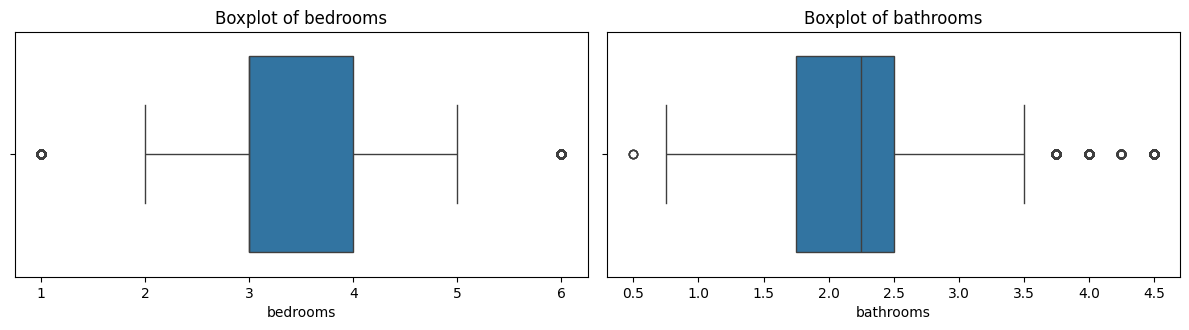

In [298]:
cols_to_check = ['bedrooms', 'bathrooms']

plt.figure(figsize=(12, 6))
for i, col in enumerate(cols_to_check, 1):
     plt.subplot(2, 2, i)
     sns.boxplot(x=df2_[col])
     plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Feature Engineering

In [299]:
df3 = df2_.copy()

**year_sold, month_sold**

In [300]:
df3['date'] = pd.to_datetime(df3['date'], format='%Y%m%dT%H%M%S')

# Bước 2: Trích xuất năm và tháng sang 2 cột mới dưới dạng số nguyên (Integer)
df3['year_sold'] = df3['date'].dt.year
df3['month_sold'] = df3['date'].dt.month

# Kiểm tra lại kết quả của vài dòng đầu tiên
print(df3[['date', 'year_sold', 'month_sold']].head())

        date  year_sold  month_sold
0 2014-10-13       2014          10
1 2014-12-09       2014          12
2 2015-02-25       2015           2
3 2014-12-09       2014          12
4 2015-02-18       2015           2


**Age**

In [301]:
df3['age'] = df3['year_sold'] - df3['yr_built']

In [302]:
# Kiểm tra xem có giá trị âm không. Những căn nhà có giá trị âm thường là được mua trước khi xây xong
df3['age'].describe()

count    21613.000000
mean        43.317818
std         29.375493
min         -1.000000
25%         18.000000
50%         40.000000
75%         63.000000
max        115.000000
Name: age, dtype: float64

In [303]:
# Căn nào số tuổi bị âm thì đưa về 0 tuổi (nhà mới tinh)
df3['age'] = np.maximum(df3['age'], 0)

In [304]:
df3['age'].describe()

count    21613.000000
mean        43.318373
std         29.374665
min          0.000000
25%         18.000000
50%         40.000000
75%         63.000000
max        115.000000
Name: age, dtype: float64

**is_renovated, years_since_renovated**

In [305]:
# 1. Tạo biến nhị phân 'is_renovated': Nếu yr_renovated > 0 thì là 1, ngược lại là 0
df3['is_renovated'] = (df3['yr_renovated'] > 0).astype(int)

# 2. Tạo biến 'years_since_renovated' với logic điều kiện:
# - Nếu nhà ĐÃ cải tạo (yr_renovated > 0): Lấy year_sold - yr_renovated
# - Nếu nhà CHƯA cải tạo (yr_renovated == 0): Số năm tính từ lần sửa cuối chính là Tuổi nhà (age)
df3['years_since_renovated'] = np.where(
    df3['yr_renovated'] > 0,
    df3['year_sold'] - df3['yr_renovated'],
    df3['age']
)

# 3. Sửa lỗi logic nếu có (Trường hợp nhà bán trước khi việc cải tạo hoàn tất hoàn toàn giống như cột age)
df3['years_since_renovated'] = np.maximum(df3['years_since_renovated'], 0)

# Kiểm tra lại kết quả một vài dòng ngẫu nhiên để xác nhận logic đúng
print(df3[['yr_built', 'yr_renovated', 'year_sold', 'age', 'is_renovated', 'years_since_renovated']].head(10))

   yr_built  yr_renovated  year_sold  age  is_renovated  years_since_renovated
0      1955             0       2014   59             0                     59
1      1951          1991       2014   63             1                     23
2      1933             0       2015   82             0                     82
3      1965             0       2014   49             0                     49
4      1987             0       2015   28             0                     28
5      2001             0       2014   13             0                     13
6      1995             0       2014   19             0                     19
7      1963             0       2015   52             0                     52
8      1960             0       2015   55             0                     55
9      2003             0       2015   12             0                     12


**has_basement**

In [306]:
df3['has_basement'] = (df3['sqft_basement'] > 0).astype(int)

In [307]:
print("Kích thước bộ dữ liệu hiện tại:", df3.shape)
print(df3[[ 'has_basement']].head())

Kích thước bộ dữ liệu hiện tại: (21613, 30)
   has_basement
0             0
1             1
2             0
3             1
4             0


In [308]:
df3.head()

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,sqft_living15,sqft_lot15,price_log,sqft_living_log,year_sold,month_sold,age,is_renovated,years_since_renovated,has_basement
0,0,7129300520,2014-10-13,221900.0,3.0,1.00,1180,5650,1.0,0,...,1340,5650,12.309987,7.074117,2014,10,59,0,59,0
1,1,6414100192,2014-12-09,538000.0,3.0,2.25,2570,7242,2.0,0,...,1690,7639,13.195616,7.852050,2014,12,63,1,23,1
2,2,5631500400,2015-02-25,180000.0,2.0,1.00,770,10000,1.0,0,...,2720,8062,12.100718,6.647688,2015,2,82,0,82,0
3,3,2487200875,2014-12-09,604000.0,4.0,3.00,1960,5000,1.0,0,...,1360,5000,13.311331,7.581210,2014,12,49,0,49,1
4,4,1954400510,2015-02-18,510000.0,3.0,2.00,1680,8080,1.0,0,...,1800,7503,13.142168,7.427144,2015,2,28,0,28,0


**distance_to_center**

In [309]:
# Tạo feature khoảng cách đến trung tâm
seattle_lat = 47.6062
seattle_long = -122.3321

df3['distance_to_center'] = np.sqrt(
    (df['lat'] - seattle_lat)**2 + 
    (df['long'] - seattle_long)**2
)

In [310]:
df3['distance_to_center'].describe()

count    21613.000000
mean         0.200795
std          0.121714
min          0.013106
25%          0.096464
50%          0.178817
75%          0.284709
max          1.022692
Name: distance_to_center, dtype: float64

In [311]:
df3[['price', 'distance_to_center']].head()

,price,distance_to_center
0,221900.0,0.121099
1,538000.0,0.115545
2,180000.0,0.164820
3,604000.0,0.104890
4,510000.0,0.287296


Text(0, 0.5, 'Price')

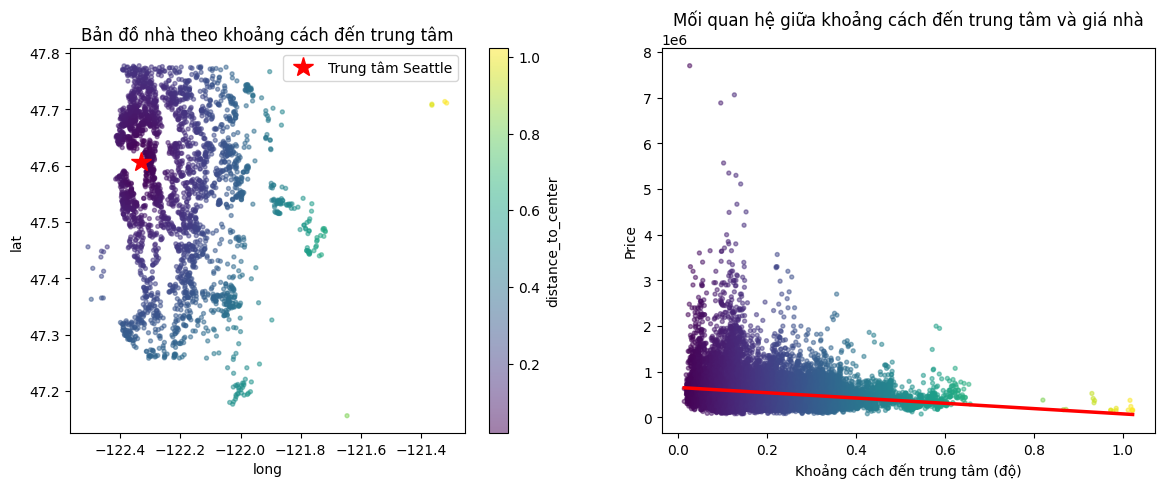

In [312]:
# Scatter: vị trí nhà & khoảng cách đến trung tâm Seattle
sample = df3.sample(3000, random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = axes[0].scatter(sample['long'], sample['lat'], c=sample['distance_to_center'],
                     cmap='viridis', alpha=0.5, s=8)
axes[0].plot(seattle_long, seattle_lat, 'r*', markersize=15, label='Trung tâm Seattle')
axes[0].set_xlabel('long'); axes[0].set_ylabel('lat')
axes[0].set_title('Bản đồ nhà theo khoảng cách đến trung tâm')
axes[0].legend()
plt.colorbar(sc, ax=axes[0], label='distance_to_center')


# Biểu đồ thứ 2: Mối quan hệ tuyến tính
axes[1].scatter(df3['distance_to_center'], df3['price'], 
                alpha=0.5, s=8, c=df3['distance_to_center'], cmap='viridis')

# Thêm đường hồi quy (regression line)
sns.regplot(x='distance_to_center', y='price', data=df3, 
            scatter=False, color='red', line_kws={'linewidth': 2.5}, ax=axes[1])

axes[1].set_title('Mối quan hệ giữa khoảng cách đến trung tâm và giá nhà')
axes[1].set_xlabel('Khoảng cách đến trung tâm (độ)')
axes[1].set_ylabel('Price')

**zipcode_freq**

In [313]:
# Frequency Encoding
zipcode_freq = df3['zipcode'].value_counts()
df3['zipcode_freq'] = df3['zipcode'].map(zipcode_freq)

In [314]:
df3[['price', 'zipcode_freq']].head()

,price,zipcode_freq
0,221900.0,262
1,538000.0,410
2,180000.0,283
3,604000.0,263
4,510000.0,441


# Drop Columns

**Select Feature**

In [315]:
df4 = df3.copy()

In [316]:
columns_to_drop = ['id', 'date', 'zipcode', 'yr_built', 'yr_renovated', 'price', 'sqft_living', 'Unnamed: 0']
df4 = df4.drop(columns=columns_to_drop)

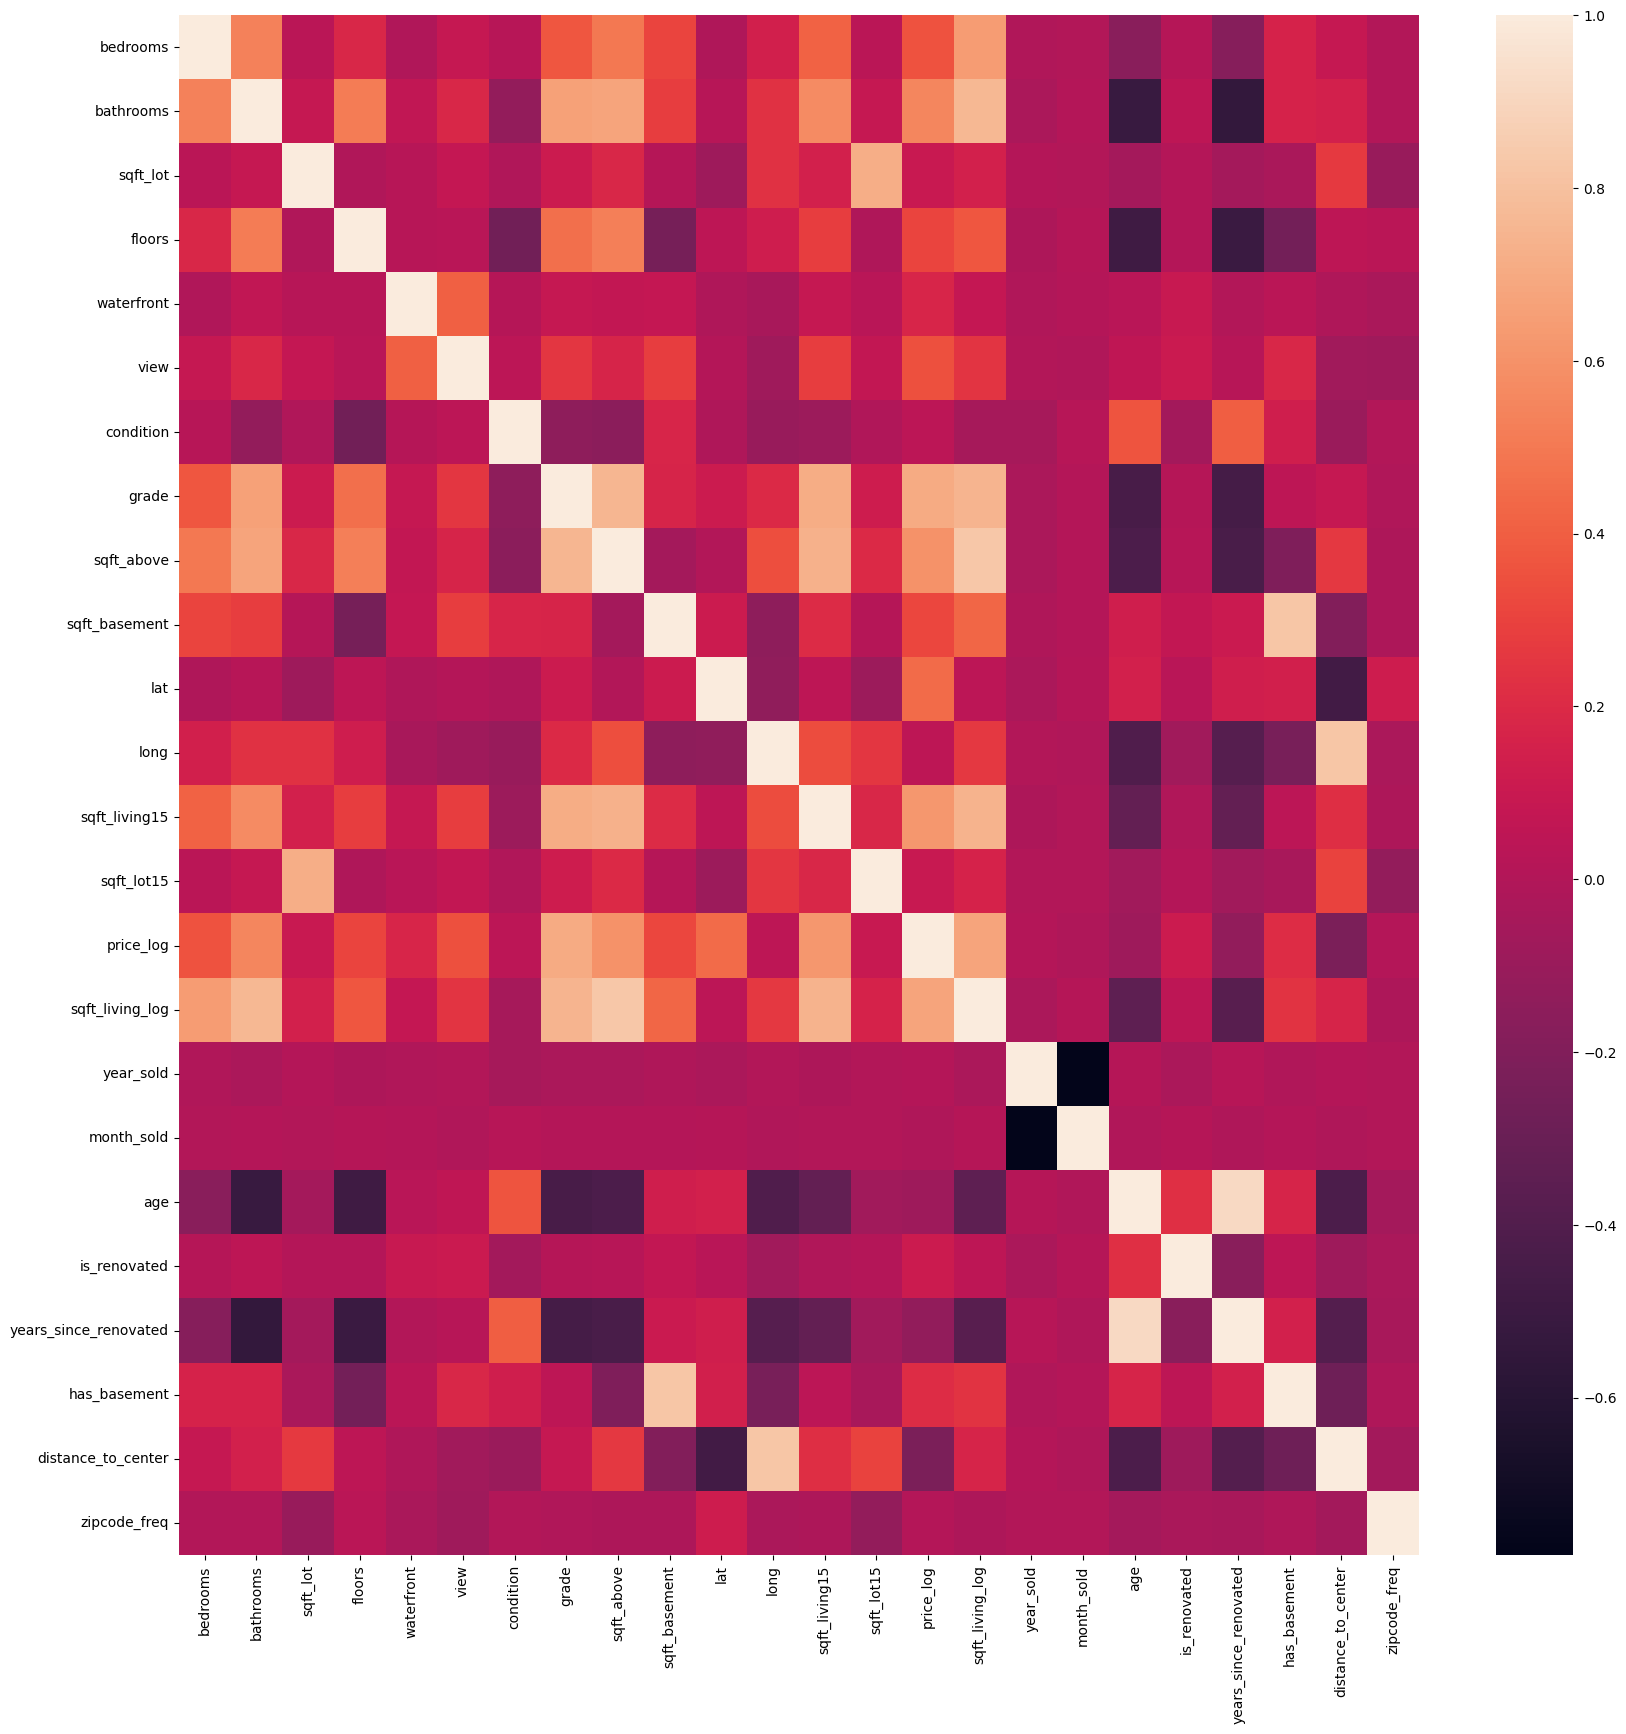

In [317]:
plt.figure(figsize=(20,20))
sns.heatmap(df4.corr(numeric_only=True), annot=False);

In [318]:
df4.corr(numeric_only=True)['price_log'].abs().sort_values(ascending=False)

price_log                1.000000
grade                    0.703634
sqft_living_log          0.674940
sqft_living15            0.619312
sqft_above               0.601802
bathrooms                0.548432
lat                      0.449174
bedrooms                 0.353481
view                     0.346522
sqft_basement            0.316970
floors                   0.310558
distance_to_center       0.222543
has_basement             0.212437
waterfront               0.174586
years_since_renovated    0.130192
is_renovated             0.114124
sqft_lot                 0.099622
sqft_lot15               0.091592
age                      0.080578
long                     0.049942
condition                0.039558
month_sold               0.013149
zipcode_freq             0.006498
year_sold                0.004679
Name: price_log, dtype: float64

**drop feature**

In [319]:
# 1. Tách biến mục tiêu y trước để đảm bảo an toàn dữ liệu
y = df3['price'] # Bản thân price này đã được bạn log transform ở bước trước rồi nhé

# 2. Tạo danh sách các cột cần loại bỏ khỏi tập các tính năng X
columns_to_drop = ['id', 'date', 'zipcode', 'yr_built', 'yr_renovated', 'price', 'sqft_living', 'Unnamed: 0', 'year_sold']

# 3. Tạo bảng X bằng cách drop danh sách trên
X = df3.drop(columns=columns_to_drop)

# 4. Kiểm tra lại kết quả cuối cùng
print("Kích thước ma trận tính năng X:", X.shape)
print("Kích thước vector mục tiêu y:", y.shape)
print("\nCác cột còn lại trong X dùng để huấn luyện MLP:\n", X.columns.tolist())

Kích thước ma trận tính năng X: (21613, 23)
Kích thước vector mục tiêu y: (21613,)

Các cột còn lại trong X dùng để huấn luyện MLP:
 ['bedrooms', 'bathrooms', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'price_log', 'sqft_living_log', 'month_sold', 'age', 'is_renovated', 'years_since_renovated', 'has_basement', 'distance_to_center', 'zipcode_freq']


# Chia tập dữ liệu

In [320]:
# Lần chia 1: Tách tập Test (15%) ra trước, giữ lại 85% làm tập tạm thời (temp)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.15, 
    random_state=42
)

# Lần chia 2: Từ 85% tập tạm thời, trích ra 17.65% làm tập Validation (tương đương 15% tổng thể)
# Phần còn lại tự động là tập Train (chiếm 70% tổng thể)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.1765, 
    random_state=42
)

# --- KHỐI LỆNH KIỂM TRA (In kết quả để xác nhận tỷ lệ) ---
total_samples = len(X)
print("BÁO CÁO KẾT QUẢ CHIA TẬP DỮ LIỆU:")
print(f"Tổng số mẫu ban đầu: {total_samples} dòng\n")

print(f" Tập TRAIN      : {X_train.shape[0]} dòng (Chiếm {X_train.shape[0]/total_samples:.1%})")
print(f" Tập VALIDATION : {X_val.shape[0]} dòng (Chiếm {X_val.shape[0]/total_samples:.1%})")
print(f" Tập TEST       : {X_test.shape[0]} dòng (Chiếm {X_test.shape[0]/total_samples:.1%})")

# Xác nhận cấu trúc của các ma trận tính năng
print(f"\nKích thước ma trận tính năng tập Train (X_train): {X_train.shape}")

BÁO CÁO KẾT QUẢ CHIA TẬP DỮ LIỆU:
Tổng số mẫu ban đầu: 21613 dòng

 Tập TRAIN      : 15128 dòng (Chiếm 70.0%)
 Tập VALIDATION : 3243 dòng (Chiếm 15.0%)
 Tập TEST       : 3242 dòng (Chiếm 15.0%)

Kích thước ma trận tính năng tập Train (X_train): (15128, 23)


# Feature Scaling

In [321]:
# Lưu bản chưa scale để so sánh trước/sau StandardScaler
X_train_raw = X_train.copy()
X_val_raw = X_val.copy()
X_test_raw = X_test.copy()

In [322]:
scaler = StandardScaler()

# Fit chỉ trên train, tránh data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [323]:
X_train = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_val = pd.DataFrame(X_val_scaled, columns=X.columns, index=X_val.index)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print('StandardScaler: fit trên Train, transform trên Val & Test')
print(f'X_train mean (gần 0): {X_train.mean().mean():.4f}')
print(f'X_train std  (gần 1): {X_train.std().mean():.4f}')

StandardScaler: fit trên Train, transform trên Val & Test
X_train mean (gần 0): -0.0000
X_train std  (gần 1): 1.0000


# Kiểm tra lần cuối & Lưu dữ liệu

**Kiểm tra**

In [324]:
print('=== Shape của 3 tập ===')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}, y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')

print('\n=== Missing values ===')
print(f'X_train: {X_train.isnull().sum().sum()}')
print(f'X_val:   {X_val.isnull().sum().sum()}')
print(f'X_test:  {X_test.isnull().sum().sum()}')
print(f'y_train: {y_train.isnull().sum().sum()}')
print(f'y_val:   {y_val.isnull().sum().sum()}')
print(f'y_test:  {y_test.isnull().sum().sum()}')

print('\n=== Tổng kết ===')
print(f'Số features: {X_train.shape[1]}')
print(f'Tổng cột (features + target): {X_train.shape[1] + 1}')
print('Dữ liệu đã sạch và sẵn sàng để huấn luyện!')

=== Shape của 3 tập ===
X_train: (15128, 23), y_train: (15128,)
X_val:   (3243, 23), y_val:   (3243,)
X_test:  (3242, 23), y_test:  (3242,)

=== Missing values ===
X_train: 0
X_val:   0
X_test:  0
y_train: 0
y_val:   0
y_test:  0

=== Tổng kết ===
Số features: 23
Tổng cột (features + target): 24
Dữ liệu đã sạch và sẵn sàng để huấn luyện!


**Lưu dữ liệu**

In [325]:
# Lưu X (features) riêng từng tập
X_train.to_csv('X_train.csv', index=False)
X_val.to_csv('X_val.csv', index=False)
X_test.to_csv('X_test.csv', index=False)

In [326]:
# Lưu y (target) riêng từng tập
y_train.to_csv('y_train.csv', index=False)
y_val.to_csv('y_val.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

In [327]:
# Lưu tập gộp (features + price) để load 1 file
train_full = pd.concat([X_train, y_train], axis=1)
val_full = pd.concat([X_val, y_val], axis=1)
test_full = pd.concat([X_test, y_test], axis=1)

train_full.to_csv('train_housing.csv', index=False)
val_full.to_csv('val_housing.csv', index=False)
test_full.to_csv('test_housing.csv', index=False)